In [61]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder

from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [62]:
df = pd.read_pickle('sessions_eda.pkl')

In [63]:
df.columns.tolist()

['visit_time',
 'visit_number',
 'utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_screen_resolution',
 'device_browser',
 'geo_country',
 'geo_city',
 'target',
 'visit_month',
 'visit_day',
 'visit_weekday']

In [64]:
df.isna().sum().sort_values(ascending=False) # Проверяем есть ли пропуски

visit_time                  0
visit_number                0
utm_source                  0
utm_medium                  0
utm_campaign                0
utm_adcontent               0
utm_keyword                 0
device_category             0
device_os                   0
device_brand                0
device_screen_resolution    0
device_browser              0
geo_country                 0
geo_city                    0
target                      0
visit_month                 0
visit_day                   0
visit_weekday               0
dtype: int64

In [65]:
df.info() # Проверяем типы данных

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   visit_time                object
 1   visit_number              int64 
 2   utm_source                object
 3   utm_medium                object
 4   utm_campaign              object
 5   utm_adcontent             object
 6   utm_keyword               object
 7   device_category           object
 8   device_os                 object
 9   device_brand              object
 10  device_screen_resolution  object
 11  device_browser            object
 12  geo_country               object
 13  geo_city                  object
 14  target                    int64 
 15  visit_month               int32 
 16  visit_day                 int32 
 17  visit_weekday             int32 
dtypes: int32(3), int64(2), object(13)
memory usage: 234.2+ MB


In [66]:
df['visit_time'].head()

0    14:36:32
1    08:21:30
2    02:42:06
3    05:00:00
4    05:00:00
Name: visit_time, dtype: object

In [67]:
# Делаем фичеиндиниринг
df['visit_hour'] = pd.to_datetime(
    df['visit_time'],
    format='%H:%M:%S'
).dt.hour

df = df.drop(columns=['visit_time'])

In [68]:
x = df.drop(columns=['target'])
y = df['target']

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

Обучим модель CarBoost

In [70]:
cat_features = x_train.select_dtypes(include='object').columns.tolist()
print(cat_features)

['utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent', 'utm_keyword', 'device_category', 'device_os', 'device_brand', 'device_screen_resolution', 'device_browser', 'geo_country', 'geo_city']


In [71]:
model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    eval_metric='AUC',
    random_seed=42,
    verbose=100
)

model.fit(x_train, y_train, cat_features=cat_features)

0:	total: 865ms	remaining: 4m 18s
100:	total: 1m 52s	remaining: 3m 41s
200:	total: 3m 38s	remaining: 1m 47s
299:	total: 5m 26s	remaining: 0us


CatBoostClassifier(depth=6, eval_metric='AUC', iterations=300, learning_rate=0.1, random_seed=42, verbose=100)

In [72]:
y_pred_proba = model.predict_proba(x_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_pred_proba)

print('ROC_AUC:', roc_auc)

ROC_AUC: 0.7346063089747409


Обучим модель Logistic Regression

In [73]:
x_lr = x.copy()

cat_cols = x_lr.select_dtypes(include='object').columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
x_lr[cat_cols] = encoder.fit_transform(x_lr[cat_cols])

In [74]:
x_train_lr, x_test_lr, y_train_lr, y_test_lr = train_test_split(x_lr, y, test_size=0.2, random_state=42, stratify=y)

In [75]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='liblinear',
)

lr.fit(x_train_lr, y_train_lr)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The 

In [76]:
y_pred_lr = lr.predict_proba(x_test_lr)[:, 1]

roc_auc_lr = roc_auc_score(y_test_lr, y_pred_lr)

print('Logistic Regression ROC_AUC:', roc_auc_lr)

Logistic Regression ROC_AUC: 0.6259563349495967


Обучим модель RandomForestClassifier

In [77]:
x_rf = x.copy()

cat_cols = x_rf.select_dtypes(include='object').columns

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

x_rf[cat_cols] = encoder.fit_transform(x_rf[cat_cols])

In [78]:
x_train_rf, x_test_rf, y_train_rf, y_test_rf = train_test_split(x_rf, y, test_size=0.2, random_state=42, stratify=y)

In [79]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(x_train_rf, y_train_rf)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [80]:
y_pred_rf = rf.predict_proba(x_test_rf)[:, 1]

roc_auc_rf = roc_auc_score(y_test_rf, y_pred_rf)

print('RandomForest ROC_AUC:', roc_auc_rf)

RandomForest ROC_AUC: 0.6510751081741276


In [81]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'CatBoost'],
    'ROC_AUC': [roc_auc_lr, roc_auc_rf, roc_auc]
})

print(results)

                 Model   ROC_AUC
0  Logistic Regression  0.625956
1        Random Forest  0.651075
2             CatBoost  0.734606


Были протестированы три алгоритма: Logistic Regression, Random Forest и CatBoost. Наилучший результат ROC-AUC показала модель CatBoost(0.73). Это связано с тем, что CatBoost эффектно работает с большим количеством категориальных признаков и автоматически выполняет их обработку. В качестве финальной модели для решения задачи была выбрана CatBoost.

In [82]:
importance = model.get_feature_importance()

feature_importance = pd.DataFrame({
    'Feature': x_train.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
feature_importance.head(15)

,Feature,Importance
4,utm_adcontent,28.415916
2,utm_medium,12.452254
3,utm_campaign,11.637839
1,utm_source,11.517642
13,visit_month,9.840871
0,visit_number,9.670912
7,device_os,2.867894
16,visit_hour,1.977505
14,visit_day,1.802939
12,geo_city,1.737405


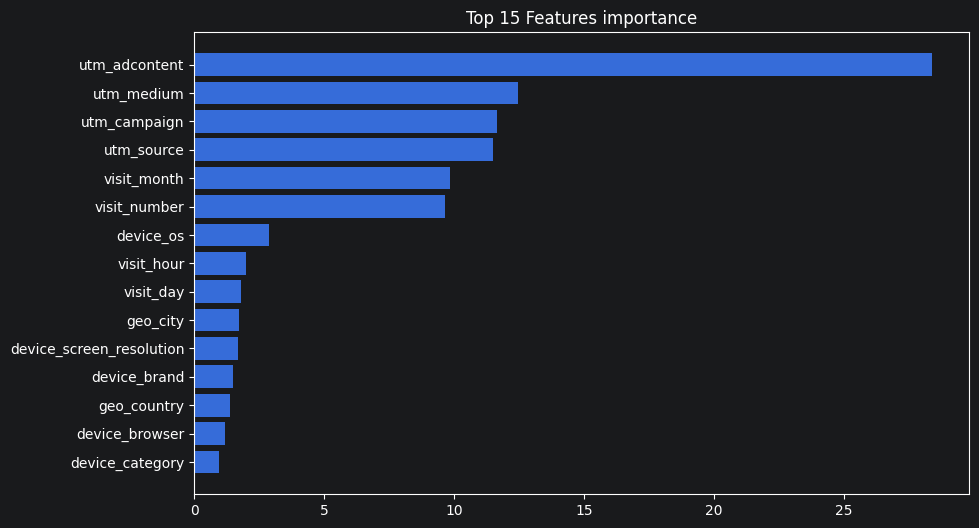

In [83]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.gca().invert_yaxis()
plt.title('Top 15 Features importance')
plt.show()

Для интерпретации модели был проведён анализ важности признаков (Feature Importance). Наиболее значимыми признаками оказались utm_adcontent, utm_medium, utm_campaign и utm_source. Это показывает, что вероятность совершения пользователем целевого действия в значительной степени определяется характеристиками рекламного трафика и маркетинговых кампаний.

Среди значимых факторов также оказались visit_month и visit_number, что свидетельствует о влиянии времени посещения сайта и пользовательской активности на вероятность конверсии.

Наименьшее влияние на предсказания модели оказали характеристики устройства пользователя и географические признаки.

In [84]:
with open('model.pkl', 'wb') as f:
    pickle.dump(model, f)